# Problem Statement:
### Decoding India's Western Export Landscape: A Predictive Analytics Approach to Identify Emerging Trends and Actionable Insights from Complex Trade Data from 2015 to 2022.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\veda_\Desktop\Data Analysis Innomatics\Project Presentation\exports_to_western_countries.csv")

In [3]:
df.sample(5)

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
2190519,300177,2023-04-01,Spain,ESP,724.0,Europe,150,Southern Europe,39,32041571,Vat Brown 1(Brown Br),Kgs,0.10,2.92,0.00
1681822,1681822,2015-11-01,Bolivia,BOL,68.0,Americas,19,Latin America and the Caribbean,419,87032191,Motor Car Wth Cylndr Cpcty<=1000 Wth Sprk-Igntn,Nos,0.15,473.25,0.72
4091738,2201396,2016-08-01,Kingdom of the Netherlands,NLD,528.0,Europe,150,Western Europe,155,84099111,"Valves,Inlet And Exhaust",Kgs,0.76,7.10,0.01
3769089,1878747,2018-06-01,Estonia,EST,233.0,Europe,150,Northern Europe,154,42023910,Jewellery Box,Nos,0.40,1.25,0.00
892697,892697,2021-03-01,Nicaragua,NIC,558.0,Americas,19,Latin America and the Caribbean,419,30049074,"Propranolol, Metoprolol, Atenolol And Labetalol",Kgs,4.25,95.00,0.13


# Cleaning the Data

In [4]:
# 1. Drop rows with NaN values
df = df.dropna()

In [5]:
df.isna().sum()

id                 0
date               0
country_name       0
alpha_3_code       0
country_code       0
region             0
region_code        0
sub_region         0
sub_region_code    0
hs_code            0
commodity          0
unit               0
value_qt           0
value_rs           0
value_dl           0
dtype: int64

In [6]:
# 2. Drop duplicates (if there are any present)
df = df.drop_duplicates()

In [7]:
# 'value_dl' has many 0 values which needs to be converted from inr to usd

(df['value_dl'] == 0).sum()

1588016

In [8]:
# So, we need perform next step:
# 3. Converting the 0 values in value_dl (from inr to usd)

df['value_dl'] = df.apply( lambda row: row['value_rs'] / 85.5 if row['value_dl'] == 0 else row['value_dl'], axis=1)

In [9]:
(df['value_dl'] == 0).sum()

0

In [10]:
# 4. Converting export values to numeric (in case of bad entries)

df['value_rs'] = pd.to_numeric(df['value_rs'])
df['value_dl'] = pd.to_numeric(df['value_dl'])
df['value_qt'] = pd.to_numeric(df['value_qt'])

In [11]:
# 5. Converting date column dt to datetime

df['date'] = pd.to_datetime(df['date'])

In [12]:
# 6. Extracting & creating new columns of : year and month (for time-based analysis) and unit values

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

## Cleaned data

In [13]:
df.head(3)

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl,year,month
0,0,2022-01-01,United States of America,USA,840.0,Americas,19,Northern America,21,2062900,"Othr Edible Offal Of Bovine Animals,Frozen",Kgs,50.00,39.21,0.050000,2022,1
1,1,2022-01-01,United States of America,USA,840.0,Americas,19,Northern America,21,3011100,Freshwater Ornamental Fish,Kgs,0.45,2.36,0.027602,2022,1
2,2,2022-01-01,United States of America,USA,840.0,Americas,19,Northern America,21,3023200,Yellowfin Tunas Fresh Or Chilled,Kgs,2.20,9.62,0.010000,2022,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4951464 entries, 0 to 4962647
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   date             datetime64[ns]
 2   country_name     object        
 3   alpha_3_code     object        
 4   country_code     float64       
 5   region           object        
 6   region_code      int64         
 7   sub_region       object        
 8   sub_region_code  int64         
 9   hs_code          int64         
 10  commodity        object        
 11  unit             object        
 12  value_qt         float64       
 13  value_rs         float64       
 14  value_dl         float64       
 15  year             int32         
 16  month            int32         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(4), object(6)
memory usage: 642.2+ MB


#
# Exploratory Data Analysis (EDA)
#

## 1. Export value of India over the years

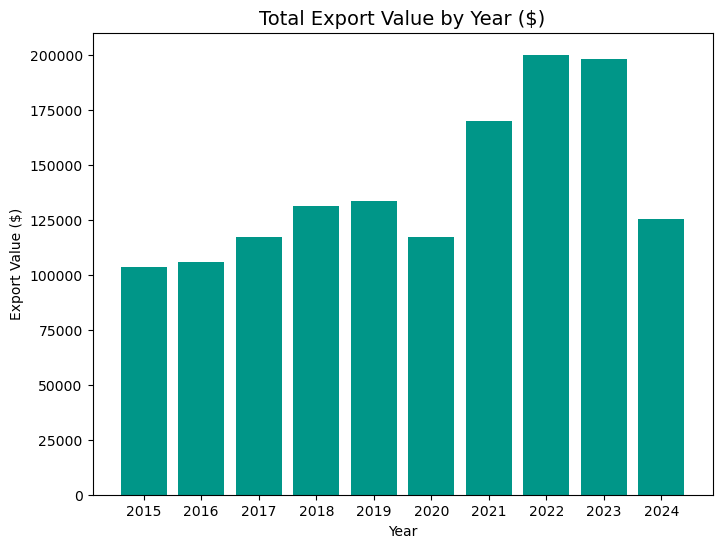

In [27]:
import matplotlib.pyplot as plt

yearly_export = df.groupby('year')['value_dl'].sum()
# print(yearly_export)

plt.figure(figsize=(8, 6))
plt.bar(yearly_export.index.astype(str), yearly_export.values, color='#009688')

plt.title('Total Export Value by Year ($)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Export Value ($)')
plt.show()


## 2. Monthly Export Trend

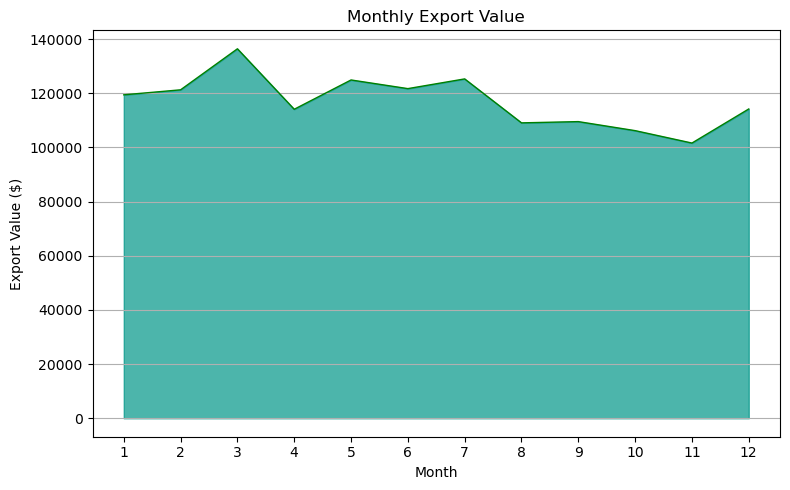

In [31]:
import matplotlib.pyplot as plt

monthly_export = df.groupby('month')['value_dl'].sum()

plt.figure(figsize=(8, 5))
plt.fill_between(monthly_export.index, monthly_export.values, color='#009688', alpha=0.7)
plt.plot(monthly_export.index, monthly_export.values, color='green', linestyle='-', linewidth=1)

plt.title('Monthly Export Value')
plt.xlabel('Month')
plt.ylabel('Export Value ($)')

plt.grid(axis='y', linestyle='-',)
plt.xticks(monthly_export.index)  # Ensure all months are displayed
plt.tight_layout()
plt.show()

## 3. Most exported commodities by value

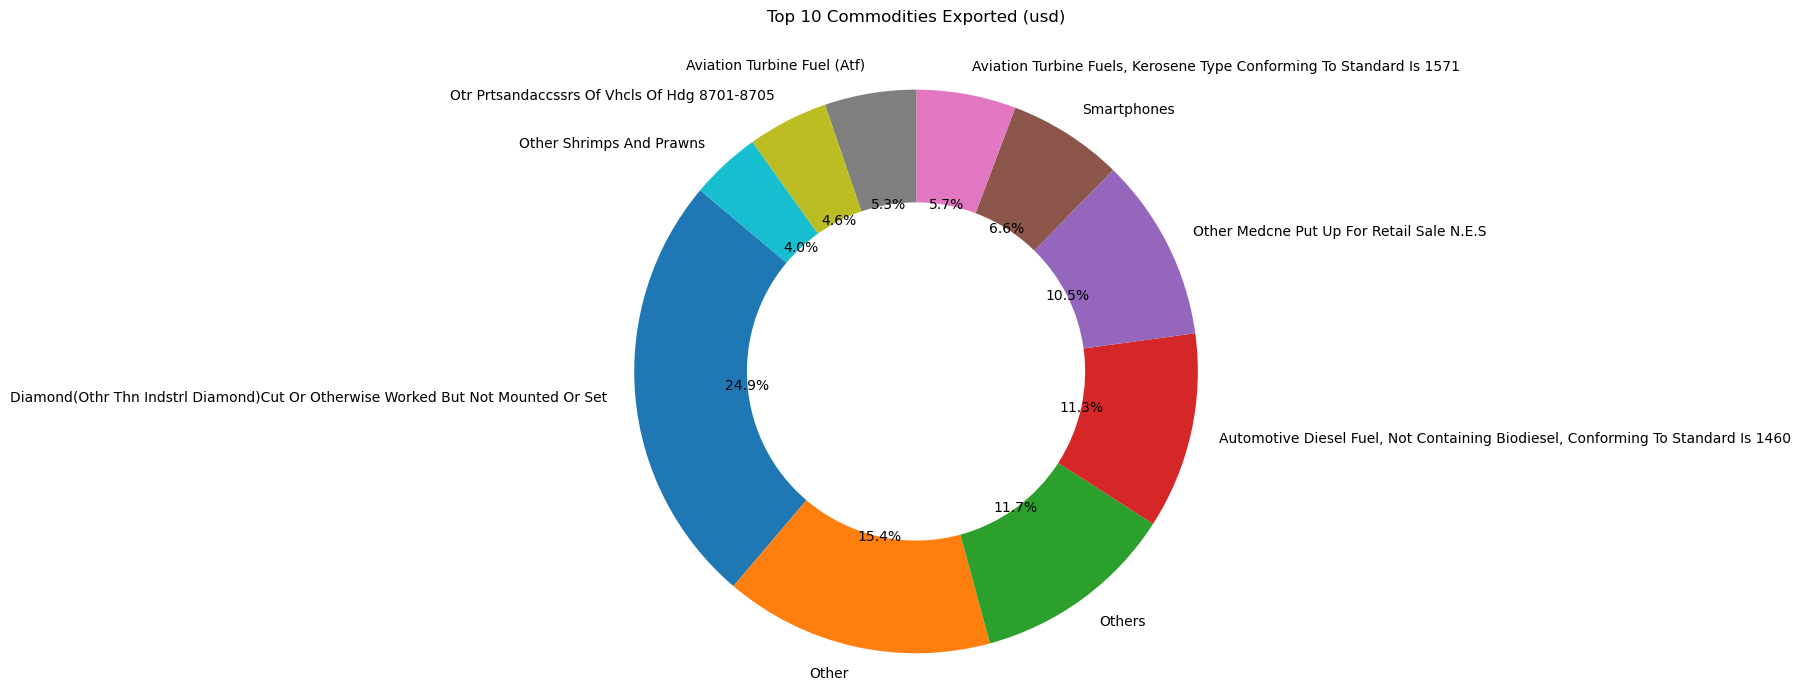

In [20]:
top_commodities = df.groupby('commodity')['value_dl'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(top_commodities.values, labels=top_commodities.index,
                                   autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors,
                                   wedgeprops=dict(width=0.4))

plt.title('Top 10 Commodities Exported (usd)', pad=30)
plt.axis('equal')
plt.show()


## 4. Commodity Diversity Based on Country

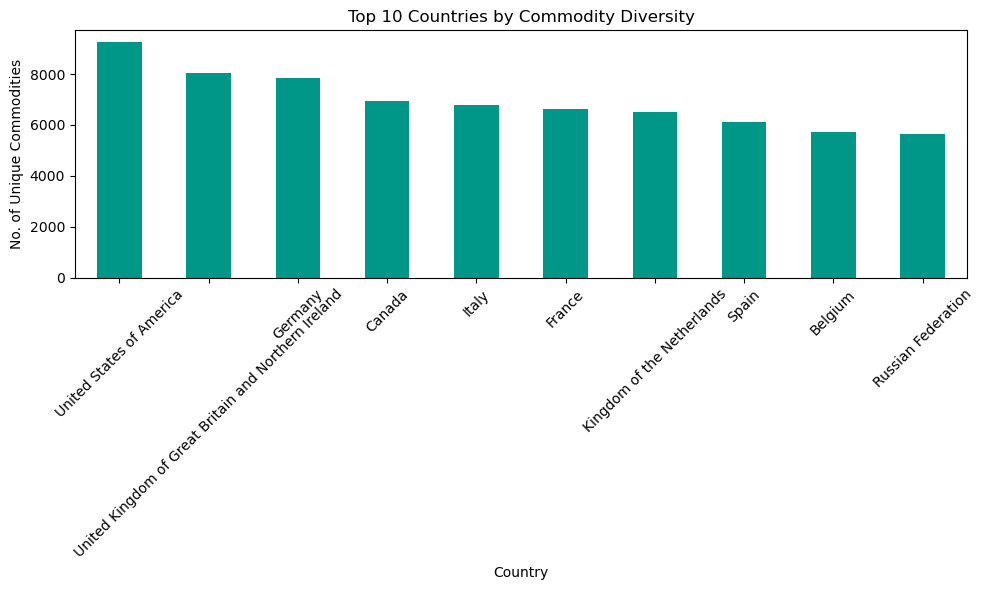

In [32]:
diversity = df.groupby("country_name")["commodity"].nunique().sort_values(ascending=False)

diversity.head(10).plot(kind='bar', figsize=(10, 6), color='#009688')
plt.title("Top 10 Countries by Commodity Diversity")
plt.ylabel("No. of Unique Commodities")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# print(diversity.head(10))


## 5. Commodity Diversity Based on Region

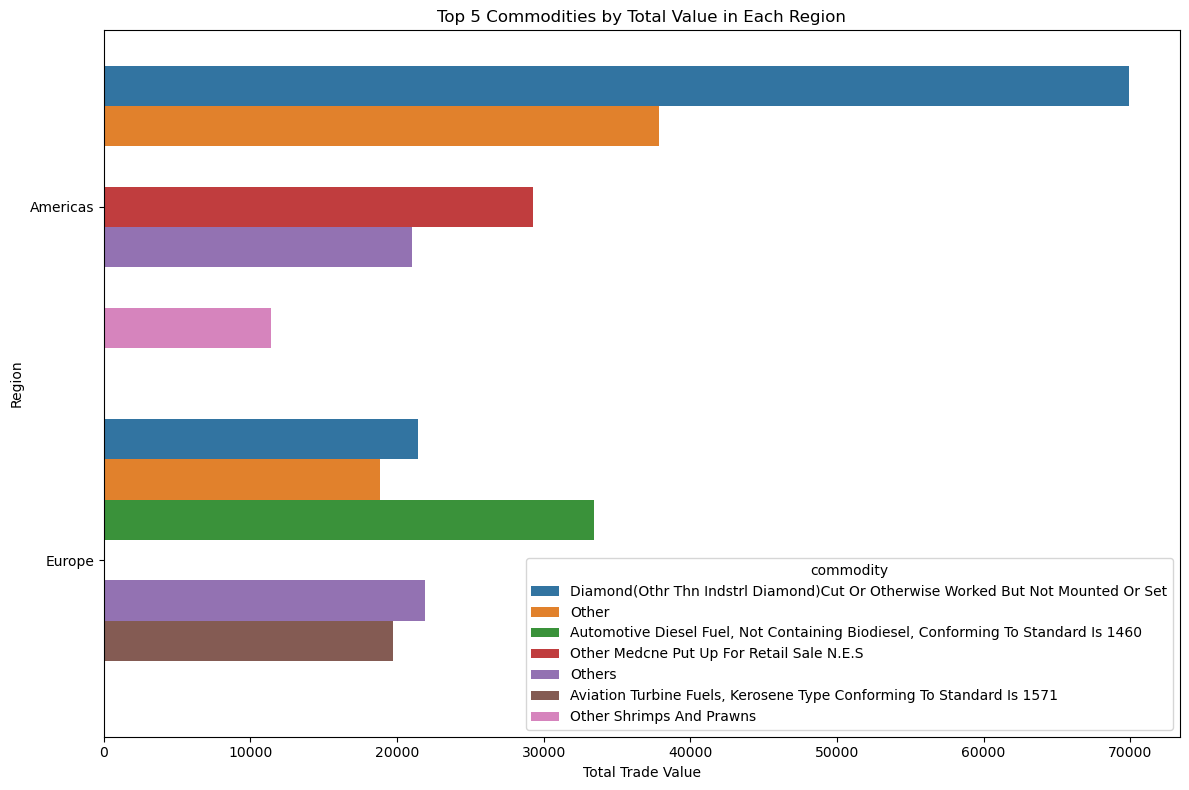

In [23]:
import seaborn as sns
region_commodity_value = df.groupby(['region', 'commodity'])['value_dl'].sum().sort_values(ascending=False)

top_n = 5

# Visualization (Top N commodities per region)
top_region_commodities = region_commodity_value.groupby(level=0).head(top_n).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_region_commodities, y='region', x='value_dl', hue='commodity')
plt.title(f'Top {top_n} Commodities by Total Value in Each Region')
plt.ylabel('Region')
plt.xlabel('Total Trade Value')
plt.tight_layout()
plt.show()

## 6. Commodity Diversity Based on Region

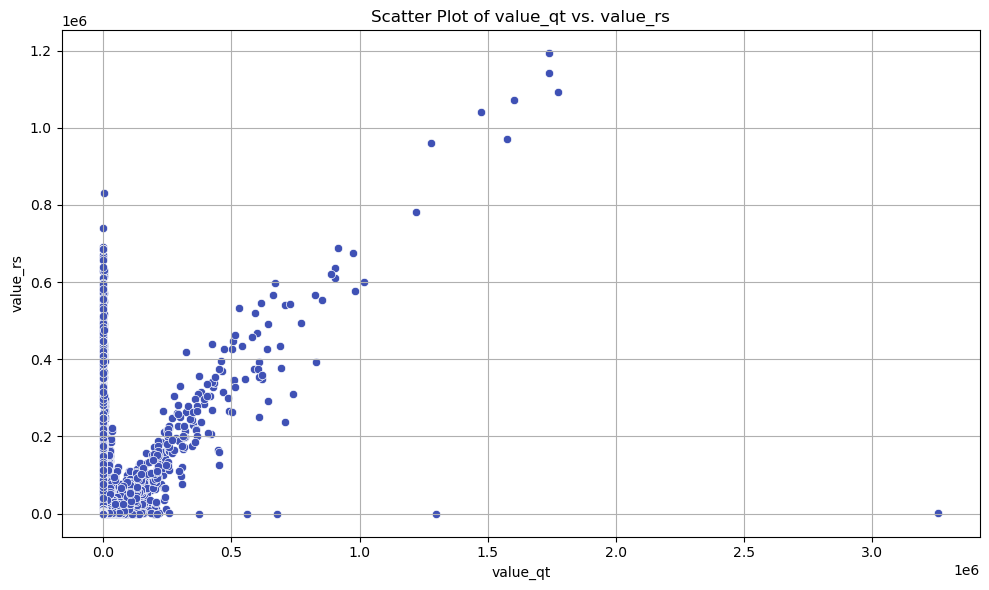

In [33]:
x_column = 'value_qt'  # Quantity Value
y_column = 'value_rs'  # RS Value

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=x_column, y=y_column, color='#3F51B5')
plt.title(f'Scatter Plot of {x_column} vs. {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. New trade partners year over year

In [25]:

yearly_countries = df.groupby("year")["country_name"].unique().to_dict()

new_partners = {}
years = sorted(yearly_countries.keys())

for i in range(1, len(years)):
    prev_year = set(yearly_countries[years[i-1]])
    curr_year = set(yearly_countries[years[i]])
    new_partners[years[i]] = list(curr_year - prev_year)

for year, countries in new_partners.items():
    print(f"\n New trading partners in {year}:")
    print(", ".join(countries) if countries else "None")



 New trading partners in 2016:
None

 New trading partners in 2017:
Jersey, Guernsey, Saint Pierre and Miquelon, Holy See(Vatican City), Greenland, Sint Maarten (Dutch part)

 New trading partners in 2018:
Falkland Islands (Malvinas)

 New trading partners in 2019:
Sint Maarten (Dutch part)

 New trading partners in 2020:
Svalbard and Jan Mayen

 New trading partners in 2021:
Falkland Islands (Malvinas)

 New trading partners in 2022:
Sint Maarten (Dutch part), Czechia

 New trading partners in 2023:
Svalbard and Jan Mayen, Falkland Islands (Malvinas)

 New trading partners in 2024:
Guernsey


# 8. Commodity Dependency by Country

In [34]:
# Total export value per country
total_per_country = df.groupby('country_name')['value_rs'].sum()

# Export value per country and commodity
commodity_per_country = df.groupby(['country_name', 'commodity'])['value_rs'].sum()

# Calculate share of each commodity in a country's total export
share = (commodity_per_country / total_per_country).reset_index()
share.columns = ['country_name', 'commodity', 'share']

# Filter countries where one commodity contributes more than 80%
high_dependency_df = share[share['share'] > 0.8].copy()

# Convert share to percentage for readability
high_dependency_df['share'] = (high_dependency_df['share'] * 100).round(2)


In [35]:
high_dependency_df

,country_name,commodity,share
71027,Falkland Islands (Malvinas),Other Garments Of Cotton,92.24
71055,Faroe Islands,Made Up Fishing Nets Othr Than Nylon,81.61
97396,Guernsey,Jewellery Of Gold Set With Diamond,96.16
119448,Jersey,Sim Cards,100.00
178632,Sint Maarten (Dutch part),"Of Gold, Studded With Diamonds Of Heading 7102",87.49
191311,Svalbard and Jan Mayen,Rice Parboiled,98.91
